In [1]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from collections import Counter

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## PPP

In [2]:
random_state = 42

In [3]:
classification_reports = []
classification_report_keys = []

### Data

In [4]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


### Undersampling

In [5]:
X = df.drop(columns='Fraud')
y = df['Fraud']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 968437, 1: 95})
Resampled dataset shape: Counter({0: 950, 1: 95})


### Split Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Baseline Models
#### (No parameter optimization, feature scaling, or cross validation)

#### Linear Regression

In [7]:
model = LogisticRegression()

In [8]:
model.fit(X_train, y_train)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)

In [10]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline Logistic Regression')

              precision    recall  f1-score   support

           0       0.99      0.89      0.94       190
           1       0.45      0.89      0.60        19

    accuracy                           0.89       209
   macro avg       0.72      0.89      0.77       209
weighted avg       0.94      0.89      0.91       209



#### Ridge

In [11]:
from sklearn.linear_model import RidgeClassifier


ridge_model = RidgeClassifier(random_state=random_state)

In [12]:
ridge_model.fit(X_train, y_train)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=3.15646e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None
,solver,'auto'
,positive,False
,random_state,42


In [13]:
y_pred = ridge_model.predict(X_test)

In [14]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline Ridge Classifier')


              precision    recall  f1-score   support

           0       0.98      0.95      0.97       190
           1       0.62      0.79      0.70        19

    accuracy                           0.94       209
   macro avg       0.80      0.87      0.83       209
weighted avg       0.95      0.94      0.94       209



#### Lasso

In [15]:
lasso_model = LogisticRegression(penalty='l1', solver='liblinear')

In [16]:
lasso_model.fit(X_train, y_train)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred = lasso_model.predict(X_test)

In [18]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline L1 (Lasso) Logistic Regression')

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       190
           1       0.70      0.74      0.72        19

    accuracy                           0.95       209
   macro avg       0.84      0.85      0.84       209
weighted avg       0.95      0.95      0.95       209



### Scaling Data

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Parameter Tuning

#### Logistic Regression

In [20]:
# We can only tune the C (float) and Class_weight to tryout balanced. 

In [21]:
# cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
from sklearn.model_selection import LeaveOneOut, StratifiedKFold


cv = StratifiedKFold(n_splits=5)
# cv = loo = LeaveOneOut()

In [22]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    # class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight='balanced',
        C=c,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

log_reg_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_log_reg_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_log_reg_unscaled_recall_optuna_results)

[I 2026-06-26 21:32:33,761] A new study created in memory with name: no-name-42709f4e-2e40-4f4d-ba8f-28b76bea54d9
[I 2026-06-26 21:32:35,167] Trial 0 finished with value: 0.9091666666666667 and parameters: {'C': 0.9559326925973288}. Best is trial 0 with value: 0.9091666666666667.
[I 2026-06-26 21:32:36,341] Trial 1 finished with value: 0.9225000000000001 and parameters: {'C': 0.6168658410843856}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-26 21:32:37,396] Trial 2 finished with value: 0.9225000000000001 and parameters: {'C': 0.6473087376115968}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-26 21:32:38,392] Trial 3 finished with value: 0.9091666666666667 and parameters: {'C': 0.9373539331223826}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-26 21:32:38,410] Trial 4 finished with value: 0.9225000000000001 and parameters: {'C': 0.07021934188550406}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-26 21:32:38,428] Trial 5 finished with 

,number,value,datetime_start,datetime_complete,duration,params_C,state
40,40,0.935,2026-06-26 21:32:39.055919,2026-06-26 21:32:39.079169,0 days 00:00:00.023250,0.004132,COMPLETE
41,41,0.935,2026-06-26 21:32:39.079169,2026-06-26 21:32:39.095230,0 days 00:00:00.016061,0.026903,COMPLETE
38,38,0.935,2026-06-26 21:32:39.024168,2026-06-26 21:32:39.039831,0 days 00:00:00.015663,0.035338,COMPLETE
36,36,0.935,2026-06-26 21:32:38.990574,2026-06-26 21:32:39.008302,0 days 00:00:00.017728,0.025454,COMPLETE
71,71,0.935,2026-06-26 21:32:39.511458,2026-06-26 21:32:39.523619,0 days 00:00:00.012161,0.003723,COMPLETE


In [23]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    # class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight='balanced',
        C=c,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

log_reg_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_log_reg_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_log_reg_unscaled_f1_optuna_results)

[I 2026-06-26 21:32:39,979] A new study created in memory with name: no-name-9c93d7cb-9ab2-462f-b1bc-62c7922b98e3
[I 2026-06-26 21:32:39,997] Trial 0 finished with value: 0.7266693866449068 and parameters: {'C': 0.7282696287077277}. Best is trial 0 with value: 0.7266693866449068.
[I 2026-06-26 21:32:40,020] Trial 1 finished with value: 0.726482873851295 and parameters: {'C': 0.81067104344882}. Best is trial 0 with value: 0.7266693866449068.
[I 2026-06-26 21:32:40,033] Trial 2 finished with value: 0.6974716009259402 and parameters: {'C': 0.04969119845259524}. Best is trial 0 with value: 0.7266693866449068.
[I 2026-06-26 21:32:40,045] Trial 3 finished with value: 0.719498746867168 and parameters: {'C': 0.9541879353695332}. Best is trial 0 with value: 0.7266693866449068.
[I 2026-06-26 21:32:40,057] Trial 4 finished with value: 0.719498746867168 and parameters: {'C': 0.9506101062636002}. Best is trial 0 with value: 0.7266693866449068.
[I 2026-06-26 21:32:40,069] Trial 5 finished with value

,number,value,datetime_start,datetime_complete,duration,params_C,state
0,0,0.726669,2026-06-26 21:32:39.979013,2026-06-26 21:32:39.997910,0 days 00:00:00.018897,0.728270,COMPLETE
11,11,0.726669,2026-06-26 21:32:40.136481,2026-06-26 21:32:40.148043,0 days 00:00:00.011562,0.507531,COMPLETE
7,7,0.726669,2026-06-26 21:32:40.081991,2026-06-26 21:32:40.093483,0 days 00:00:00.011492,0.478487,COMPLETE
5,5,0.726669,2026-06-26 21:32:40.057791,2026-06-26 21:32:40.069242,0 days 00:00:00.011451,0.544371,COMPLETE
34,34,0.726669,2026-06-26 21:32:40.527540,2026-06-26 21:32:40.542094,0 days 00:00:00.014554,0.521887,COMPLETE


##### Tryout best params

In [24]:
log_reg_recall_optimized_model = LogisticRegression(C=0.769946, class_weight='balanced', random_state=random_state)
log_reg_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = log_reg_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Logistic Regression (Recall Optimized)')

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       190
           1       0.52      0.84      0.64        19

    accuracy                           0.91       209
   macro avg       0.75      0.88      0.80       209
weighted avg       0.94      0.91      0.92       209



In [25]:
log_reg_f1_optimized_model = LogisticRegression(C=0.315005, class_weight='balanced', random_state=random_state)
log_reg_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = log_reg_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Logistic Regression (F1 Optimized)')

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       190
           1       0.52      0.84      0.64        19

    accuracy                           0.91       209
   macro avg       0.75      0.88      0.80       209
weighted avg       0.94      0.91      0.92       209



[I 2026-06-26 21:32:41,687] A new study created in memory with name: no-name-11c67644-44d3-4699-883f-61d311bba772
[I 2026-06-26 21:32:41,710] Trial 0 finished with value: 0.9350000000000002 and parameters: {'C': 0.01715214521796133}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:41,736] Trial 1 finished with value: 0.9216666666666666 and parameters: {'C': 0.0019696617137927672}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:41,752] Trial 2 finished with value: 0.9216666666666666 and parameters: {'C': 0.0011608699755215925}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:41,768] Trial 3 finished with value: 0.9225000000000001 and parameters: {'C': 0.22652659028891464}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:41,779] Trial 4 finished with value: 0.9350000000000002 and parameters: {'C': 0.005858898173953291}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:41,791] Trial 5 finis

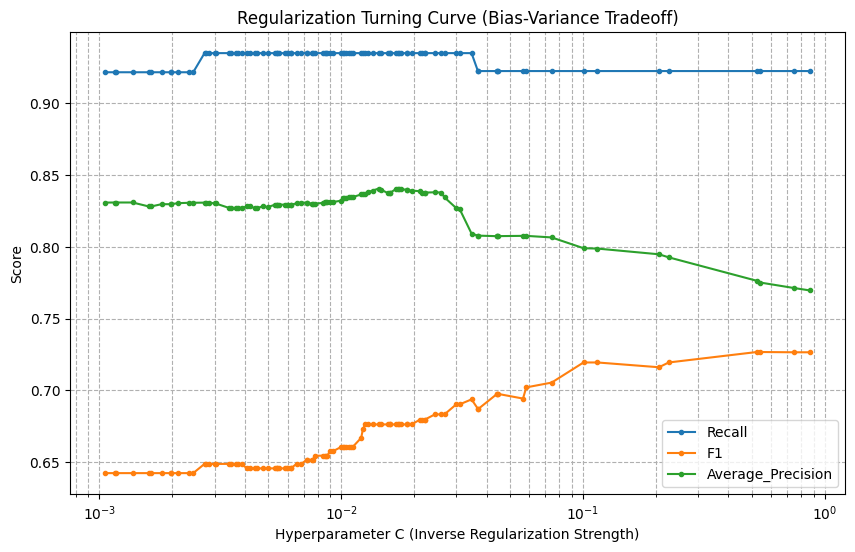

In [26]:
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, average_precision_score, f1_score

def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0, log=True) # Log scale is best for regularization
    # class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight='balanced', 
        C=c, 
        random_state=random_state,
        max_iter=1000
    )
    
    # Track multiple metrics
    scoring = {
        'recall': 'recall',
        'f1': 'f1',
        'average_precision': 'average_precision'
    }
    
    scores = cross_validate(
        model, X=X_train_scaled, y=y_train, cv=cv, 
        scoring=scoring, n_jobs=-1
    )
    
    # Calculate means across the cross-validation folds
    mean_recall = np.mean(scores['test_recall'])
    mean_f1 = np.mean(scores['test_f1'])
    mean_ap = np.mean(scores['test_average_precision'])
    
    # Store these as trial attributes so you can access them later
    trial.set_user_attr("f1", mean_f1)
    trial.set_user_attr("average_precision", mean_ap)
    
    # Return primary metric (recall, as in your original code)
    return mean_recall

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

import pandas as pd
import matplotlib.pyplot as plt

# Extract C (params) and the user-defined scores from all trials
records = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        records.append({
            "C": t.params["C"],
            "Class_weight": t.params.get("Class_weight"),
            "Recall": t.value,
            "F1": t.user_attrs["f1"],
            "Average_Precision": t.user_attrs["average_precision"]
        })

results_df = pd.DataFrame(records).sort_values("C")

# Plotting the Turning Curve
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(x="C", y=["Recall", "F1", "Average_Precision"], ax=ax, style='.-')
ax.set_xscale('log')
ax.set_title("Regularization Turning Curve (Bias-Variance Tradeoff)")
ax.set_xlabel("Hyperparameter C (Inverse Regularization Strength)")
ax.set_ylabel("Score")
plt.grid(True, which="both", ls="--")
plt.show()


#### Ridge

In [27]:
# We can tune alpha and class weight

##### Recall optimized

In [28]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.001, 1.0)
    class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight=class_weight,
        alpha=alpha,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

ridge_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_ridge_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_ridge_unscaled_recall_optuna_results)

[I 2026-06-26 21:32:43,895] A new study created in memory with name: no-name-4583b4de-c4cd-431f-9132-4af1aedd9fb7
[I 2026-06-26 21:32:43,916] Trial 0 finished with value: 0.9350000000000002 and parameters: {'alpha': 0.7003496467186082, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:43,942] Trial 1 finished with value: 0.9350000000000002 and parameters: {'alpha': 0.6507734441035478, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:43,958] Trial 2 finished with value: 0.9350000000000002 and parameters: {'alpha': 0.03150204494258231, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:43,974] Trial 3 finished with value: 0.9350000000000002 and parameters: {'alpha': 0.8445266505343059, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:43,995] Trial 4 finished with value: 0.9350000000000002 and parameter

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_class_weight,state
0,0,0.935,2026-06-26 21:32:43.895183,2026-06-26 21:32:43.916725,0 days 00:00:00.021542,0.700350,balanced,COMPLETE
1,1,0.935,2026-06-26 21:32:43.916725,2026-06-26 21:32:43.942929,0 days 00:00:00.026204,0.650773,balanced,COMPLETE
2,2,0.935,2026-06-26 21:32:43.942929,2026-06-26 21:32:43.958770,0 days 00:00:00.015841,0.031502,balanced,COMPLETE
3,3,0.935,2026-06-26 21:32:43.958770,2026-06-26 21:32:43.974688,0 days 00:00:00.015918,0.844527,balanced,COMPLETE
4,4,0.935,2026-06-26 21:32:43.974688,2026-06-26 21:32:43.995030,0 days 00:00:00.020342,0.195529,balanced,COMPLETE


##### Tryout best params

In [29]:
ridge_recall_optimized_model = RidgeClassifier(alpha=0.039558, class_weight='balanced', random_state=random_state)
ridge_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = ridge_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Ridge Classifier (Recall Optimized)')

              precision    recall  f1-score   support

           0       0.98      0.88      0.93       190
           1       0.42      0.84      0.56        19

    accuracy                           0.88       209
   macro avg       0.70      0.86      0.75       209
weighted avg       0.93      0.88      0.90       209



##### F1 optimized

In [30]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.001, 1.0)
    class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight=class_weight,
        alpha=alpha,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

ridge_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_ridge_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_ridge_unscaled_f1_optuna_results)

[I 2026-06-26 21:32:45,753] A new study created in memory with name: no-name-a9b16dfd-7375-4f04-bbd2-8ff64dded780
[I 2026-06-26 21:32:45,780] Trial 0 finished with value: 0.7599343185550083 and parameters: {'alpha': 0.6253315200335114, 'class_weight': None}. Best is trial 0 with value: 0.7599343185550083.
[I 2026-06-26 21:32:45,795] Trial 1 finished with value: 0.6647694334650855 and parameters: {'alpha': 0.7345784404327041, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7599343185550083.
[I 2026-06-26 21:32:45,810] Trial 2 finished with value: 0.6647694334650855 and parameters: {'alpha': 0.6245146414592143, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7599343185550083.
[I 2026-06-26 21:32:45,831] Trial 3 finished with value: 0.7599343185550083 and parameters: {'alpha': 0.6397078877777983, 'class_weight': None}. Best is trial 0 with value: 0.7599343185550083.
[I 2026-06-26 21:32:45,847] Trial 4 finished with value: 0.7599343185550083 and parameters: {'alpha': 

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_class_weight,state
79,79,0.763744,2026-06-26 21:32:47.075234,2026-06-26 21:32:47.091643,0 days 00:00:00.016409,0.716674,None,COMPLETE
84,84,0.763744,2026-06-26 21:32:47.161918,2026-06-26 21:32:47.174131,0 days 00:00:00.012213,0.713555,None,COMPLETE
77,77,0.763744,2026-06-26 21:32:47.040167,2026-06-26 21:32:47.058027,0 days 00:00:00.017860,0.713702,None,COMPLETE
76,76,0.763744,2026-06-26 21:32:47.018192,2026-06-26 21:32:47.040167,0 days 00:00:00.021975,0.717769,None,COMPLETE
69,69,0.763744,2026-06-26 21:32:46.903101,2026-06-26 21:32:46.918288,0 days 00:00:00.015187,0.713023,None,COMPLETE


##### Tryout best params

In [31]:
ridge_f1_optimized_model = RidgeClassifier(alpha=0.364826, class_weight='balanced', random_state=random_state)
ridge_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = ridge_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Ridge Classifier (F1 Optimized)')

              precision    recall  f1-score   support

           0       0.98      0.88      0.93       190
           1       0.41      0.84      0.55        19

    accuracy                           0.88       209
   macro avg       0.70      0.86      0.74       209
weighted avg       0.93      0.88      0.89       209



[I 2026-06-26 21:32:47,465] A new study created in memory with name: no-name-3cccaa29-6d32-4bd9-8c47-591d79a547dc
[I 2026-06-26 21:32:47,477] Trial 0 finished with value: 0.9350000000000002 and parameters: {'alpha': 1453.1292546079737}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:47,495] Trial 1 finished with value: 0.9350000000000002 and parameters: {'alpha': 0.02145773405866766}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:47,512] Trial 2 finished with value: 0.9350000000000002 and parameters: {'alpha': 705.3829994953376}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:47,525] Trial 3 finished with value: 0.9350000000000002 and parameters: {'alpha': 139.56601123413157}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:47,537] Trial 4 finished with value: 0.9350000000000002 and parameters: {'alpha': 0.012850891768281004}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:47,551] T

,alpha,recall,precision,f1
45,0.001005,0.935,0.516189,0.664769
90,0.001097,0.935,0.516189,0.664769
12,0.001779,0.935,0.516189,0.664769
64,0.002339,0.935,0.516189,0.664769
17,0.002552,0.935,0.516189,0.664769


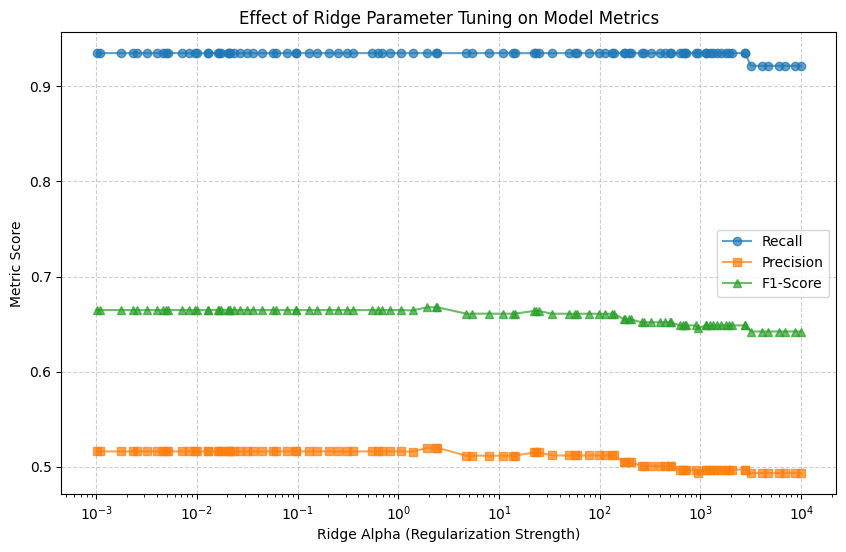

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate

def objective(trial):
    # Suggest hyperparameters
    alpha = trial.suggest_float("alpha", 0.001, 1_0000, log=True)
    # class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight='balanced', 
        alpha=alpha, 
        random_state=random_state
    )
    
    # Evaluate multiple metrics simultaneously using cross_validate
    scoring_metrics = ['recall', 'precision', 'f1']
    cv_results = cross_validate(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Calculate the mean for each metric
    mean_recall = np.mean(cv_results['test_recall'])
    mean_precision = np.mean(cv_results['test_precision'])
    mean_f1 = np.mean(cv_results['test_f1'])
    
    # Save precision and F1 to trial metadata
    trial.set_user_attr("precision", mean_precision)
    trial.set_user_attr("f1", mean_f1)
    
    # Optuna will optimize based on recall
    return mean_recall

# Run the optimization study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

# Convert study results to a DataFrame including user attributes
df_results = study.trials_dataframe()

# Rename columns for simpler plotting access
df_results = df_results.rename(columns={
    "value": "recall",
    "params_alpha": "alpha",
    "user_attrs_precision": "precision",
    "user_attrs_f1": "f1"
})

# Sort by alpha to ensure the plot line flows correctly
df_results = df_results.sort_values(by="alpha")

# Display the top 5 trials based on recall
top_5_results = df_results.sort_values("recall", ascending=False).head(5)
display(top_5_results[["alpha", "recall", "precision", "f1"]])

# Create a line plot to visualize the tuning effect
plt.figure(figsize=(10, 6))
ax = plt.gca() 
ax.set_xscale('log')
plt.plot(df_results["alpha"], df_results["recall"], label="Recall", marker="o", alpha=0.7)
plt.plot(df_results["alpha"], df_results["precision"], label="Precision", marker="s", alpha=0.7)
plt.plot(df_results["alpha"], df_results["f1"], label="F1-Score", marker="^", alpha=0.7)

ax.set_xscale('log')
plt.xlabel("Ridge Alpha (Regularization Strength)")
ax.set_xscale('log')
plt.ylabel("Metric Score")
plt.title("Effect of Ridge Parameter Tuning on Model Metrics")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


#### Lasso Logistic Regression

In [33]:
# We can only tune the C (float) and Class_weight to tryout balanced. 

In [34]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        penalty='l1', # Lasso
        class_weight=class_weight,
        C=c,
        solver='liblinear',
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, n_jobs=-1)

lasso_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_lasso_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_lasso_unscaled_recall_optuna_results)

[I 2026-06-26 21:32:49,466] A new study created in memory with name: no-name-d17b79c8-ea4a-4bd6-bbc6-e4c618e6e203
[I 2026-06-26 21:32:49,552] Trial 0 finished with value: 0.8300000000000001 and parameters: {'C': 0.45023914030674406, 'Class_weight': None}. Best is trial 0 with value: 0.8300000000000001.
[I 2026-06-26 21:32:49,556] Trial 1 finished with value: 0.8166666666666668 and parameters: {'C': 0.824988260521051, 'Class_weight': None}. Best is trial 0 with value: 0.8300000000000001.
[I 2026-06-26 21:32:49,567] Trial 2 finished with value: 0.8166666666666668 and parameters: {'C': 0.5947398851481733, 'Class_weight': None}. Best is trial 0 with value: 0.8300000000000001.
[I 2026-06-26 21:32:49,590] Trial 7 finished with value: 0.0 and parameters: {'C': 0.009470818446162526, 'Class_weight': None}. Best is trial 0 with value: 0.8300000000000001.
[I 2026-06-26 21:32:49,590] Trial 11 finished with value: 0.8166666666666668 and parameters: {'C': 0.7194581121719802, 'Class_weight': None}. B

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
14,14,0.9350,2026-06-26 21:32:49.492205,2026-06-26 21:32:49.590649,0 days 00:00:00.098444,0.200869,balanced,COMPLETE
12,12,0.9350,2026-06-26 21:32:49.491856,2026-06-26 21:32:49.590649,0 days 00:00:00.098793,0.283108,balanced,COMPLETE
9,9,0.9350,2026-06-26 21:32:49.485895,2026-06-26 21:32:49.590649,0 days 00:00:00.104754,0.285369,balanced,COMPLETE
8,8,0.9225,2026-06-26 21:32:49.483797,2026-06-26 21:32:49.592938,0 days 00:00:00.109141,0.443500,balanced,COMPLETE
10,10,0.9225,2026-06-26 21:32:49.486347,2026-06-26 21:32:49.593581,0 days 00:00:00.107234,0.903886,balanced,COMPLETE


In [35]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        penalty='l1', # Lasso
        class_weight=class_weight,
        C=c,
        solver='liblinear',
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

lasso_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_lasso_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_lasso_unscaled_f1_optuna_results)

[I 2026-06-26 21:32:49,618] A new study created in memory with name: no-name-a91f5f6f-2e12-4ad8-87c8-e7f54b70e2d9
[I 2026-06-26 21:32:49,633] Trial 0 finished with value: 0.7873388732578681 and parameters: {'C': 0.7059935137558566, 'Class_weight': None}. Best is trial 0 with value: 0.7873388732578681.
[I 2026-06-26 21:32:49,647] Trial 1 finished with value: 0.7998768472906403 and parameters: {'C': 0.2658563648907566, 'Class_weight': None}. Best is trial 1 with value: 0.7998768472906403.
[I 2026-06-26 21:32:49,660] Trial 2 finished with value: 0.726482873851295 and parameters: {'C': 0.7564413753824965, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.7998768472906403.
[I 2026-06-26 21:32:49,672] Trial 3 finished with value: 0.7262129683182315 and parameters: {'C': 0.4647502299722401, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.7998768472906403.
[I 2026-06-26 21:32:49,705] Trial 4 finished with value: 0.7818216318785579 and parameters: {'C': 0.9373142388208104, '

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
6,6,0.805522,2026-06-26 21:32:49.720180,2026-06-26 21:32:49.745153,0 days 00:00:00.024973,0.443134,None,COMPLETE
12,12,0.805522,2026-06-26 21:32:49.859588,2026-06-26 21:32:49.884715,0 days 00:00:00.025127,0.205816,None,COMPLETE
13,13,0.805522,2026-06-26 21:32:49.885353,2026-06-26 21:32:49.902011,0 days 00:00:00.016658,0.165399,None,COMPLETE
11,11,0.799877,2026-06-26 21:32:49.830317,2026-06-26 21:32:49.859588,0 days 00:00:00.029271,0.259354,None,COMPLETE
10,10,0.799877,2026-06-26 21:32:49.804923,2026-06-26 21:32:49.830317,0 days 00:00:00.025394,0.382747,None,COMPLETE


##### Tryout best params

In [36]:
lasso_recall_optimized_model = LogisticRegression(
    penalty='l1', # Lasso
    C=0.248927, 
    class_weight=None,
    solver='saga',
    random_state=random_state
)
lasso_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = lasso_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Lasso Classifier (Recall Optimized)')

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.97      0.97       190
           1       0.71      0.79      0.75        19

    accuracy                           0.95       209
   macro avg       0.85      0.88      0.86       209
weighted avg       0.95      0.95      0.95       209



In [37]:
lasso_f1_optimized_model = LogisticRegression(
    penalty='l1', # Lasso
    C=0.496023, 
    class_weight=None,
    solver='saga',
    random_state=random_state
)
lasso_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = lasso_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Lasso Classifier (F1 Optimized)')

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.96      0.97       190
           1       0.68      0.79      0.73        19

    accuracy                           0.95       209
   macro avg       0.83      0.88      0.85       209
weighted avg       0.95      0.95      0.95       209



[I 2026-06-26 21:32:50,067] A new study created in memory with name: no-name-e8c055f2-2f3b-4c7f-9aba-58e90ef7a4d2
[I 2026-06-26 21:32:50,143] Trial 0 finished with value: 0.9350000000000002 and parameters: {'C': 0.002886393599948221}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:50,187] Trial 2 finished with value: 0.9225000000000001 and parameters: {'C': 0.534030386621455}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:50,203] Trial 3 finished with value: 0.9225000000000001 and parameters: {'C': 0.6510079865019937}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:50,203] Trial 1 finished with value: 0.9350000000000002 and parameters: {'C': 0.016732001473573923}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:50,241] Trial 20 finished with value: 0.9350000000000002 and parameters: {'C': 0.005459323603184451}. Best is trial 0 with value: 0.9350000000000002.
[I 2026-06-26 21:32:50,241] Trial 5 finished 

,number,Recall,datetime_start,datetime_complete,duration,C,F1-Score,Precision,state
0,0,0.935,2026-06-26 21:32:50.067968,2026-06-26 21:32:50.143800,0 days 00:00:00.075832,0.002886,0.664282,0.51564,COMPLETE
1,1,0.935,2026-06-26 21:32:50.067968,2026-06-26 21:32:50.203003,0 days 00:00:00.135035,0.016732,0.664282,0.51564,COMPLETE
6,6,0.935,2026-06-26 21:32:50.078550,2026-06-26 21:32:50.241634,0 days 00:00:00.163084,0.004103,0.664282,0.51564,COMPLETE
5,5,0.935,2026-06-26 21:32:50.078550,2026-06-26 21:32:50.241634,0 days 00:00:00.163084,0.006515,0.664282,0.51564,COMPLETE
22,22,0.935,2026-06-26 21:32:50.203003,2026-06-26 21:32:50.257365,0 days 00:00:00.054362,0.009821,0.664282,0.51564,COMPLETE


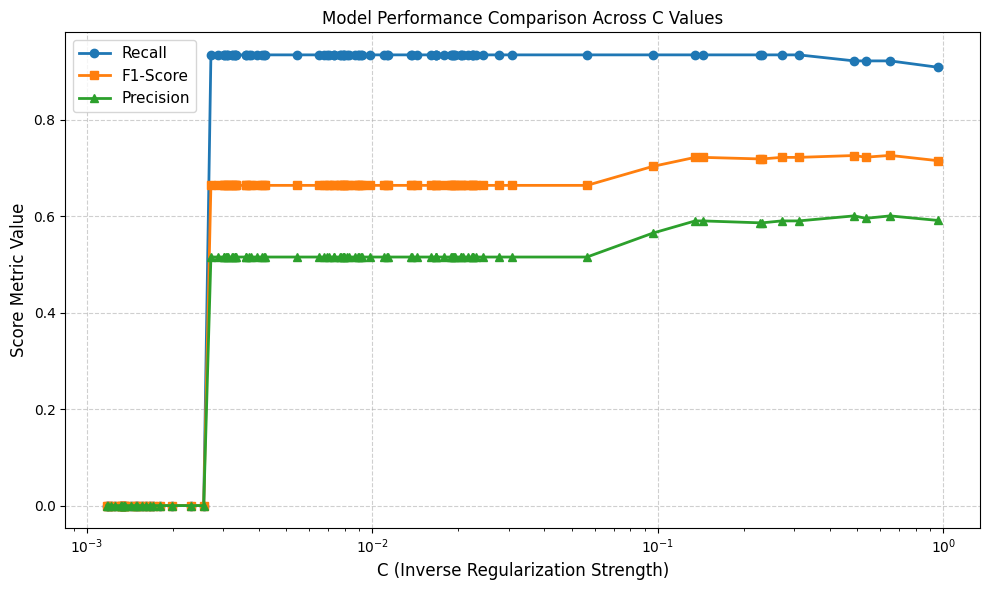

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

def objective(trial):
    c = trial.suggest_float("C", 0.001, 1, log=True)
    
    model = LogisticRegression(
        penalty='l1',
        class_weight='balanced',
        C=c,
        solver='liblinear',
        random_state=random_state # Ensure random_state is defined in your environment
    )
    
    # Evaluate multiple metrics simultaneously
    scoring_metrics = ['recall', 'f1', 'precision']
    cv_results = cross_validate(
        model, 
        X=X_train_scaled, # Ensure X_train_scaled is defined
        y=y_train,        # Ensure y_train is defined
        cv=cv,            # Ensure cv object is defined
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Calculate mean scores
    mean_recall = cv_results['test_recall'].mean()
    mean_f1 = cv_results['test_f1'].mean()
    # FIXED: Key must match the 'test_<metric>' pattern from scoring_metrics
    mean_precision = cv_results['test_precision'].mean() 
    
    # Store additional metrics inside the trial attributes
    trial.set_user_attr("f1", mean_f1)
    trial.set_user_attr("precision", mean_precision)
    
    # Optuna still optimizes strictly based on recall
    return mean_recall

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, n_jobs=-1)

# Extract data including the user attributes
df_results = study.trials_dataframe()

# Clean up column names for easier plotting
df_results = df_results.rename(columns={
    'params_C': 'C',
    'value': 'Recall',
    'user_attrs_f1': 'F1-Score',
    'user_attrs_precision': 'Precision'
})

# Display Top 5 results sorted by Recall
top_5_results = df_results.sort_values("Recall", ascending=False).head(5)
display(top_5_results)

# Sort by C value to make line plotting continuous
df_plot = df_results.sort_values(by="C")

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_xscale('log')
# Plot each metric against C
plt.plot(df_plot['C'], df_plot['Recall'], marker='o', label='Recall', linewidth=2)
plt.plot(df_plot['C'], df_plot['F1-Score'], marker='s', label='F1-Score', linewidth=2)
plt.plot(df_plot['C'], df_plot['Precision'], marker='^', label='Precision', linewidth=2)

# Formatting the visual aesthetics
plt.title('Model Performance Comparison Across C Values')
plt.xlabel('C (Inverse Regularization Strength)', fontsize=12)
plt.ylabel('Score Metric Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


### Conclusions

In [39]:
reports_df = pd.concat(classification_reports, keys=classification_report_keys)
reports_df

precision    recall  \
Baseline Logistic Regression            0              0.988304  0.889474   
                                        1              0.447368  0.894737   
                                        accuracy       0.889952  0.889952   
                                        macro avg      0.717836  0.892105   
                                        weighted avg   0.939128  0.889952   
Baseline Ridge Classifier               0              0.978378  0.952632   
                                        1              0.625000  0.789474   
                                        accuracy       0.937799  0.937799   
                                        macro avg      0.801689  0.871053   
                                        weighted avg   0.946253  0.937799   
Baseline L1 (Lasso) Logistic Regression 0              0.973545  0.968421   
                                        1              0.700000  0.736842   
                                        accuracy       0.947368  0.947368   
                                        macro avg      0.836772  0.852632   
                                        weighted avg   0.948677  0.947368   
Logistic Regression (Recall Optimized)  0              0.983146  0.921053   
                                        1              0.516129  0.842105   
                                        accuracy       0.913876  0.913876   
                                        macro avg      0.749638  0.881579   
                                        weighted avg   0.940690  0.913876   
Logistic Regression (F1 Optimized)      0              0.983146  0.921053   
                                        1              0.516129  0.842105   
                                        accuracy       0.913876  0.913876   
                                        macro avg      0.749638  0.881579   
                                        weighted avg   0.940690  0.913876   
Ridge Classifier (Recall Optimized)     0              0.982456  0.884211   
                                        1              0.421053  0.842105   
                                        accuracy       0.880383  0.880383   
                                        macro avg      0.701754  0.863158   
                                        weighted avg   0.931419  0.880383   
Ridge Classifier (F1 Optimized)         0              0.982353  0.878947   
                                        1              0.410256  0.842105   
                                        accuracy       0.875598  0.875598   
                                        macro avg      0.696305  0.860526   
                                        weighted avg   0.930344  0.875598   
Lasso Classifier (Recall Optimized)     0              0.978723  0.968421   
                                        1              0.714286  0.789474   
                                        accuracy       0.952153  0.952153   
                                        macro avg      0.846505  0.878947   
                                        weighted avg   0.954684  0.952153   
Lasso Classifier (F1 Optimized)         0              0.978610  0.963158   
                                        1              0.681818  0.789474   
                                        accuracy       0.947368  0.947368   
                                        macro avg      0.830214  0.876316   
                                        weighted avg   0.951629  0.947368   

                                                      f1-score     support  
Baseline Logistic Regression            0             0.936288  190.000000  
                                        1             0.596491   19.000000  
                                        accuracy      0.889952    0.889952  
                                        macro avg     0.766390  209.000000  
                                        weighted avg  0.905397  209.000000  
Baseline Ridge Classifier               0        

Since this is a fraud dataset, the Lasso Recall optimized model could be the best, with F1 of 0.75 for positive class.  The lasso drives the unhelpful weights to zero. 

The log reg consistently has low precision for the positive class, likely due to the multicolinearity. There could be inconsistency due to this causing large swings in the model. 

Ridge might not performed as well since coefs can be completely shrunk to 0

In [40]:
import numpy as np

pd.set_option('display.max_rows', None)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge_Coef': ridge_f1_optimized_model.coef_,
})

# Sort features by the absolute size of their coefficients
coef_df['Abs_Coefficient'] = np.abs(coef_df['Ridge_Coef'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
coef_df

,Feature,Ridge_Coef,Abs_Coefficient
39,ForgivenessDate_int,-0.636292,0.636292
38,DateApproved_int,0.336484,0.336484
0,ProcessingMethod,-0.318839,0.318839
21,OriginatingLenderState,-0.189621,0.189621
6,ServicingLenderState,0.178688,0.178688
27,ForgivenPercentage,0.155812,0.155812
29,PROCEED_Diff,-0.148566,0.148566
2,LoanStatus,-0.128188,0.128188
31,PAYROLL_PROCEED_pct,0.114106,0.114106
16,RENT_PROCEED,0.097229,0.097229


In [41]:
len(coef_df[coef_df['Abs_Coefficient'] == 0])

1

We can see 1 features coefs get shrunk to 0 by the Ridge model. This shows these features did not add additional information to the model and can be safely dropped

In [42]:
coefficients = lasso_f1_optimized_model.coef_[0]

# 3. Create a DataFrame to map features to their coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# 4. VIEW RETAINED FEATURES (Coefficient is NOT 0)
selected_features = coef_df[coef_df['Coefficient'] != 0]
print("Features Selected by Lasso:")
print(selected_features)

# 5. VIEW REJECTED FEATURES (Coefficient is exactly 0)
dropped_features = coef_df[coef_df['Coefficient'] == 0]
print("\nFeatures Ignored by Lasso:")
print(dropped_features['Feature'].tolist())

Features Selected by Lasso:
                   Feature  Coefficient
0         ProcessingMethod    -0.519262
1            BorrowerState     0.218712
2               LoanStatus    -0.251691
3                     Term    -0.043586
7      RuralUrbanIndicator     0.184038
9             LMIIndicator    -0.062952
10  BusinessAgeDescription     0.200309
11            ProjectState     0.218712
12            JobsReported    -0.081325
14         PAYROLL_PROCEED    -0.016060
16            RENT_PROCEED     0.152955
20            BusinessType    -0.012146
21  OriginatingLenderState    -0.199626
22                 Veteran     0.149011
23               NonProfit     0.045029
25            ApprovalDiff    -0.055810
26       NotForgivenAmount    -0.041735
27      ForgivenPercentage    -0.629629
29            PROCEED_Diff    -0.435194
37         PROCEED_Per_Job     0.166441
38        DateApproved_int    -0.052837
39     ForgivenessDate_int    -0.952909
40      LoanStatusDate_int    -0.203905

Features Ig

In [43]:
len(dropped_features)

18

Lasso dropped 18 features